# QNAM: Noncrossing additive quantile regression

QNAM predicts several conditional quantiles while constraining every intercept and term contribution to be nondecreasing across ordered quantile levels.


## Model in one view


For $\tau_1<\cdots<\tau_K$,

$$
q_{\tau_k}(x)=\beta_{0k}+\sum_j f_{jk}(x_j),
\qquad
q_{\tau_1}(x)\le\cdots\le q_{\tau_K}(x).
$$

Positive transformed increments enforce the ordering at every additive component.



QNAM estimates several conditional quantiles with the pinball loss. Rather than
fitting each level independently, it parameterizes ordered increments with a
positive transform. Cumulative summation guarantees noncrossing quantiles for
the intercept and every additive term, hence also for their total.

The quantile dimension is part of the output contract. Wider intervals describe
conditional outcome dispersion, not parameter uncertainty. Dense quantile
grids increase output size, and the minimum-increment control trades strict
separation against the ability of adjacent levels to coincide.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 180
X = pd.DataFrame({
    "x1": rng.uniform(-1.0, 1.0, n),
    "x2": rng.normal(size=n),
    "group": rng.choice(["a", "b", "c"], size=n),
})
y = (
    np.sin(np.pi * X["x1"])
    + 0.35 * X["x2"] ** 2
    + 0.30 * (X["group"] == "b")
    + rng.normal(0.0, 0.12, n)
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)


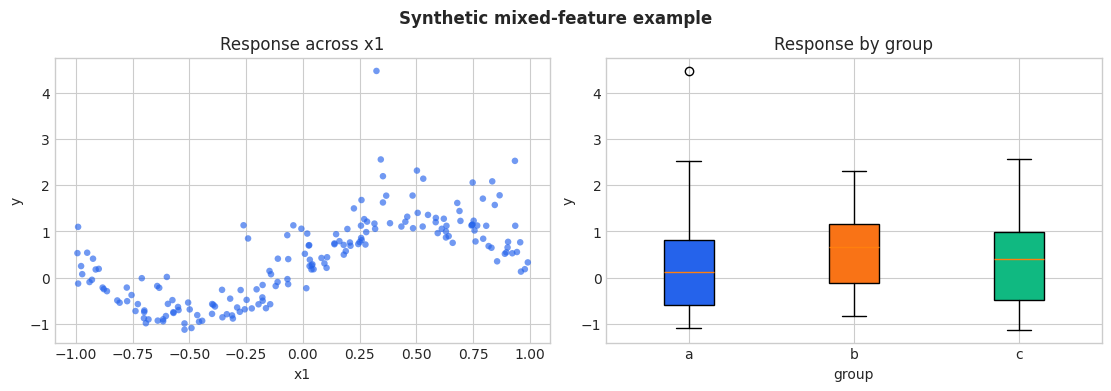

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(X["x1"], y, s=22, alpha=0.65, color=COLORS[0], edgecolor="none")
axes[0].set(title="Response across x1", xlabel="x1", ylabel="y")

group_order = ["a", "b", "c"]
group_values = [y[X["group"].to_numpy() == level] for level in group_order]
boxes = axes[1].boxplot(group_values, tick_labels=group_order, patch_artist=True)
for patch, color in zip(boxes["boxes"], COLORS, strict=False):
    patch.set_facecolor(color)
axes[1].set(title="Response by group", xlabel="group", ylabel="y")
fig.suptitle("Synthetic mixed-feature example", fontweight="bold")
plt.show()
plt.close(fig)


## Fit the model


In [3]:
from nampy.models import QNAMLSS


quantiles = [0.1, 0.5, 0.9]
model = QNAMLSS(
    layer_sizes=[32, 16],
    monotone_transform="softplus",
    min_increment=0.0,
    dropout=0.0,
    distributional_kwargs={"quantiles": quantiles},
)
model.get_params(deep=False)


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'activation': torch.nn.modules.activation.ReLU,
 'batch_norm': False,
 'dropout': 0.0,
 'feature_dropout': 0.0,
 'interaction_degree': None,
 'interactions': None,
 'intercept': True,
 'layer_norm': False,
 'layer_sizes': [32, 16],
 'lr': 0.0001,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'min_increment': 0.0,
 'monotone_transform': 'softplus',
 'norm': None,
 'skip_connections': False,
 'use_glu': False,
 'weight_decay': 1e-06,
 'feature_preprocessing': None,
 'n_bins': 64,
 'numerical_preprocessing': 'ple',
 'categorical_preprocessing': 'int',
 'use_decision_tree_bins': False,
 'binning_strategy': 'uniform',
 'task': 'regression',
 'cat_cutoff': 0.03,
 'treat_all_integers_as_numerical': False,
 'degree': 3,
 'scaling_strategy': 'minmax',
 'n_knots': 64,
 'use_decision_tree_knots': True,
 'knots_strategy': 'uniform',
 'spline_implementation': 'sklearn',
 'min_unique_vals': 5,
 'family': 'quantile',
 'distributional_kwargs': {'quantiles': [0.1, 0.5, 0.9]}}

## Model-specific controls

QNAM is intentionally distributional-only. Set quantile levels with the estimator's `distributional_kwargs`; `predict` returns one ordered column per level.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger

`Trainer.fit` stopped: `max_epochs=3` reached.


{'NLL': 2.193822145462036,
 'Pinball Loss': 2.193821851390299,
 'Median MAE': 2.3540994690589776}

,term,term_type,output,importance
0,group,main,0,0.049896
1,x1,main,1,0.037216
2,group,main,2,0.034416
3,x1,main,2,0.029837
4,group,main,1,0.026434
5,x1,main,0,0.020507
6,x2,main,0,0.015574
7,x2,main,1,0.011534
8,x2,main,2,0.011107


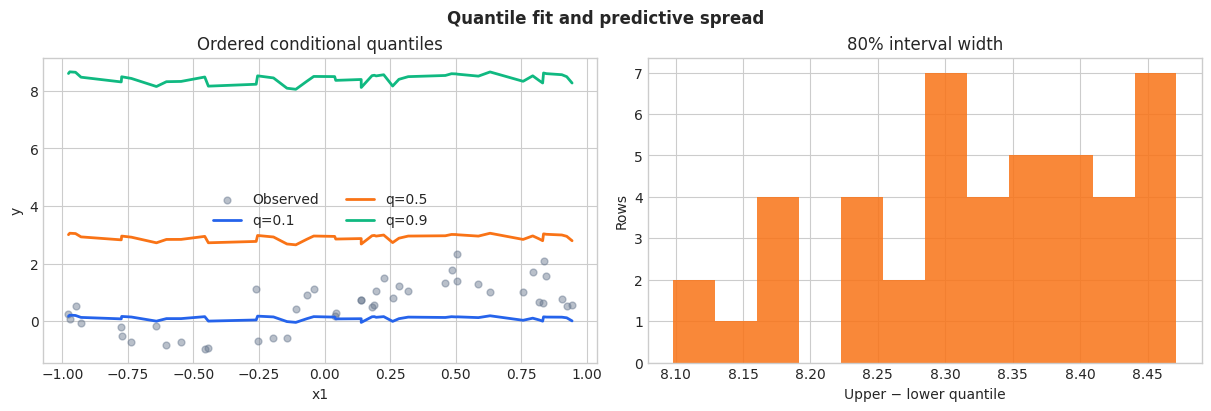

In [4]:
model.fit(
    X_train, y_train,
    max_epochs=3,
    batch_size=64,
    random_state=7,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
predicted_quantiles = model.predict(X_test)
assert np.all(np.diff(predicted_quantiles, axis=1) >= -1e-7)
score = model.score(X_test, np.asarray(y_test))
display(model.evaluate(X_test, np.asarray(y_test)))
components = model.predict_components(X_test)
explanation = model.explain_terms(X_test, max_bins=24, center=True)
importance = model.term_importance(X_test, center=True)
display(importance)

order = np.argsort(X_test["x1"].to_numpy())
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].scatter(
    X_test["x1"], y_test, s=24, alpha=0.45, color="#64748B", label="Observed"
)
for index, (quantile, color) in enumerate(zip(quantiles, COLORS, strict=False)):
    axes[0].plot(
        X_test["x1"].to_numpy()[order],
        predicted_quantiles[order, index],
        color=color,
        linewidth=2,
        label=f"q={quantile}",
    )
axes[0].set(title="Ordered conditional quantiles", xlabel="x1", ylabel="y")
axes[0].legend(frameon=False, ncol=2)

interval_width = predicted_quantiles[:, -1] - predicted_quantiles[:, 0]
axes[1].hist(interval_width, bins=12, color=COLORS[1], alpha=0.85)
axes[1].set(title="80% interval width", xlabel="Upper − lower quantile", ylabel="Rows")
fig.suptitle("Quantile fit and predictive spread", fontweight="bold")
plt.show()
plt.close(fig)


## Supported task variants

QNAM exposes `QNAMLSS` only because its output contract is an ordered quantile distribution.


In [5]:
task_variants = {"distributional_quantiles": model}


## References

- Koenker, *Quantile Regression*; NAMpy's monotone-increment parameterization enforces noncrossing outputs.
